## Performance Prediction & Composition via Stochastic Network Calculus (SNC)

This notebook implements the probabilistic end-to-end performance modeling methodology (PEGASUS) on a small synthetic
system, so that every step can be inspected and the ground truth is known:

1. **Learning:** one Gaussian Process (GP) per service predicts the execution time of an item from the configuration.
2. **Service bound:** the GP's Gaussian Moment Generating Function (MGF) goes into an SNC queueing bound, which gives
   a bound on the latency (sojourn time) of one service at arrival rate $\lambda$ that is violated with probability
   at most $\varepsilon$.
3. **Composition:** node bounds are added along the pipeline with the violation budget split over the nodes (union
   bound). This is the Probabilistic Performance Guarantee (PPG); it holds for any dependence between services.

The ground truth is a simulated queueing pipeline (Poisson arrivals, one FIFO server per service, item sizes shared
across services), so the bounds are checked against end-to-end latencies, not against execution times alone.

### Revision notes (2026-09-30)

The notebook was aligned with the testbed evaluation (`evaluation_v2`). Every changed cell is marked with
**Changed** / **New** (markdown) or `# CHANGED` / `# NEW` / `# OLD` (code); the old implementation is kept next to the
new one so that the difference stays visible.

| # | what changed | why |
|---|---|---|
| A | ground truth is a queueing pipeline with correlated items (Section 1b) | the old oracle summed independent Gaussian execution times: no queueing, no arrival rate, and independent by construction, so it could not reveal a wrong independence assumption |
| B | the service bound is an SNC queueing bound with arrival rate $\lambda$ (Section 6) | the old bound was a Chernoff bound on one execution time; it is the special case $\lambda \to 0$ of the new one |
| C | composition is the union bound with $\varepsilon / K$ per node (Section 7) | the old composition (sum of means and variances, one $\theta$) assumes independent services; it is kept as a baseline |
| D | epistemic uncertainty is used as a confidence level on the mean, not as item variance (Section 6) | adding it to every item's variance barely changes the bound; see Section 6b |
| E | test inputs are drawn from the training range; "rates" are labelled as delays; tightness is a ratio | fixes |
| F | the design-space sweep uses the PPG and the simulated oracle (Section 8); a depth study was added (Section 9) | coverage must be measured against end-to-end latency; depth is RQ2 of the paper |
| G | arrivals can be Poisson or periodic with jitter (`arrival_process`, Sections 1b and 6) | one IoT device or stream reports at a fixed rate; many unsynchronized devices together look Poisson |

In [1]:
# ==============================================================================
# Performance Prediction & Composition via SNC
# ==============================================================================

import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel as C, Matern, WhiteKernel
from sklearn.preprocessing import StandardScaler

# Set global seed for reproducibility
np.random.seed(35)

# Global SLA / Risk target across all notebook steps
alpha = 0.05  # Violation probability (alpha = 0.0001 -> 99.99% SLA guarantee)
z_score = norm.ppf(1 - alpha)

# Format dynamic percentile label (e.g., '99.99' or '95')
p_pct = (1 - alpha) * 100
p_str = f"{p_pct:.2f}".rstrip('0').rstrip('.')

# NEW: workload and ground-truth parameters
arrival_rate = 3.0        # lambda: items per second offered to the pipeline (Poisson)
# NEW (change G): arrival process of the items entering the pipeline
#   "poisson" : exponential gaps with mean 1/lambda (many unsynchronized devices)
#   "periodic": gaps of (1/lambda) * (1 + U(-arrival_jitter, arrival_jitter)) (one device or stream at a fixed rate)
arrival_process = "poisson"
arrival_jitter = 0.1      # relative half-width of the uniform jitter on periodic gaps, in [0, 1)
item_correlation = 0.7    # correlation of an item's execution-time noise across services (a large item is slow everywhere)
n_sim_items = 5000        # items per simulated run of the ground truth

# NEW: confidence level at which epistemic uncertainty enters the bound (change D)
confidence = 0.95
z_confidence = norm.ppf(confidence)

# NEW: grid of MGF parameters theta (1/s) over which every SNC bound is optimized
theta_grid = np.logspace(-1, 5, 4000)

## 1. Synthetic Data Generation
We simulate execution time demands for a pipeline of three microservices ($s_1 \to s_2 \to s_3$) driven by system parameters: [CPU, Quality, Parallelism].

Each service is described by $s = \langle r, c, \lambda \rangle$: the configuration $x = (r, c)$ = [CPU, Quality, Parallelism]
determines the execution time of an item; the arrival rate $\lambda$ determines how long items queue.
**Changed:** the training data below is unchanged (single-service measurements of execution time), but the
ground truth for latencies now also includes queueing (Section 1b).

In [2]:
def true_demand(x, service_type):
    """Simulates latency demand d(x) = f(cpu, quality, parallelism)."""
    cpu, quality, parallelism = x[:, 0], x[:, 1], x[:, 2]
    if service_type == "type_A":
        # CPU scaling increased (0.008 -> 0.040), Quality scaling increased (0.005 -> 0.030, exponent 1.2 -> 2.0)
        return 0.010 + 0.040 / cpu + 0.030 * (quality ** 2.0)
    elif service_type == "type_B":
        # CPU scaling increased (0.005 -> 0.035), Quality scaling increased (0.007 -> 0.025)
        return 0.012 + 0.035 / cpu + 0.025 * (quality ** 1.5)
    else:
        # CPU scaling increased (0.004 -> 0.030), Quality scaling increased (0.006 -> 0.020)
        return 0.008 + 0.030 / cpu + 0.020 * (quality ** 1.8)

n_train = 50
X_train = np.column_stack([
    np.random.uniform(0.5, 2.0, n_train),  # CPU
    np.random.uniform(0.5, 2.0, n_train),  # Quality
    np.random.uniform(1.0, 4.0, n_train)  # Parallelism
])

service_names = ["s1", "s2", "s3"]
service_types = ["type_A", "type_B", "type_C"]
y_train_dict = {}

# Noise scaled proportionally to the new dynamic latency range (~3% to 5% coefficient of variation)
noise_levels = {
    "s1": 0.0060,  # ~5ms std (High variance node)
    "s2": 0.0010,  # ~2ms std (Low variance / stable node)
    "s3": 0.0035   # ~3.5ms std (Medium variance node)
}

for s_name, s_type in zip(service_names, service_types):
    y_clean = true_demand(X_train, s_type)
    noise = np.random.normal(0, noise_levels[s_name], n_train)
    y_train_dict[s_name] = y_clean + noise

print("Training dataset successfully generated.")

Training dataset successfully generated.


## 1b. Ground Truth: the Pipeline as a Queueing System

**New (change A).** Items arrive at rate $\lambda$, either as a Poisson process or periodically with uniform jitter
(`arrival_process`, change G). Every service is one FIFO server; an item
leaves $s_k$ and immediately enters $s_{k+1}$ (workload propagation). The execution time of item $i$ at service $k$ is
$d_k(x) + \sigma_k z_{ik}$, where the noise $z_{ik}$ is shared across services with correlation `item_correlation`:
a large request is slow at every service. The marginal execution time of each service is exactly the one the
training data was drawn from, so the GPs are not affected.

The latency (sojourn time) of an item at a service is its queueing wait plus its execution time. The ground-truth
$(1-\alpha)$ latency quantile of a configuration is estimated from `n_sim_items` simulated items.

*Old ground truth (Section 7C, kept as a comment there):* the end-to-end latency was the sum of independent Gaussian
execution times. It had no queue, did not depend on $\lambda$, and its nodes were independent by construction.

In [3]:
# NEW (change G): inter-arrival times of the external arrival process
def sample_interarrival_times(arrival_rate, shape, rng):
    if arrival_process == "poisson":
        return rng.exponential(1.0 / arrival_rate, shape)
    if arrival_process == "periodic":
        assert 0 <= arrival_jitter < 1, "arrival_jitter must be in [0, 1)"
        return (1.0 / arrival_rate) * (1 + rng.uniform(-arrival_jitter, arrival_jitter, shape))
    raise ValueError(f"unknown arrival_process {arrival_process!r}")


# NEW: ground truth. Vectorized over configurations: x_cfgs has one row per configuration.
def simulate_pipeline(x_cfgs, path_types, path_noise_levels, arrival_rate, n_items, item_correlation, rng, warmup_share=0.1):
    """Simulates a chain of FIFO single-server services. Returns per-node latencies and end-to-end latencies,
    each with one row per configuration and one column per item (the first warmup_share of items is dropped)."""
    x_cfgs = np.atleast_2d(x_cfgs)
    n_cfgs = len(x_cfgs)
    # CHANGED (change G): was np.cumsum(rng.exponential(1.0 / arrival_rate, (n_cfgs, n_items)), axis=1)
    arrivals = np.cumsum(sample_interarrival_times(arrival_rate, (n_cfgs, n_items), rng), axis=1)
    shared_size = rng.standard_normal((n_cfgs, n_items))

    entering = arrivals
    node_latencies = []
    for s_type, noise_level in zip(path_types, path_noise_levels):
        own_noise = rng.standard_normal((n_cfgs, n_items))
        z = item_correlation * shared_size + np.sqrt(1 - item_correlation ** 2) * own_noise
        execution = np.maximum(true_demand(x_cfgs, s_type)[:, None] + noise_level * z, 0.0)

        # FIFO server: an item starts when it has arrived and the previous item has left
        leaving = np.empty_like(entering)
        previous_leaving = np.zeros(n_cfgs)
        for i in range(n_items):
            previous_leaving = np.maximum(entering[:, i], previous_leaving) + execution[:, i]
            leaving[:, i] = previous_leaving
        node_latencies.append(leaving - entering)
        entering = leaving

    kept_items = slice(int(warmup_share * n_items), None)
    return np.stack(node_latencies, axis=-1)[:, kept_items], (entering - arrivals)[:, kept_items]


def quantile_per_config(samples, level=1 - alpha):
    return np.quantile(samples, level, axis=1)


print("Ground-truth simulator ready.")

Ground-truth simulator ready.


## 2. Learning Stage (Gaussian Process Surrogate Models)

We train a GP for each service to capture execution time distributions, decomposing epistemic (model) and aleatoric (noise) uncertainties.

In [4]:
class ScaledGPRegressor:
    """
    Wrapper around GaussianProcessRegressor that handles feature (X) scaling
    and leverages native `normalize_y=True` for target scaling.

    Explicitly decomposes total predictive variance V[Y(x)] into:
    - Epistemic uncertainty: Var(f(x))
    - Aleatoric uncertainty: sigma_n^2 (from WhiteKernel, unscaled to physical units)
    """
    def __init__(self, kernel, n_restarts_optimizer=5, random_state=42):
        self.x_scaler = StandardScaler()
        self.gp = GaussianProcessRegressor(
            kernel=kernel,
            normalize_y=True,  # Handles y-scaling natively & unscales predict() outputs
            n_restarts_optimizer=n_restarts_optimizer,
            random_state=random_state
        )

    def fit(self, X, y):
        X_scaled = self.x_scaler.fit_transform(X)
        self.gp.fit(X_scaled, y)
        return self

    def predict(self, X, return_std=False, return_variance_components=False):
        X_scaled = self.x_scaler.transform(X)

        # Epistemic standard deviation sqrt(Var(f(x))) - natively unscaled by sklearn
        mu, std_epistemic = self.gp.predict(X_scaled, return_std=True)
        var_epistemic = std_epistemic ** 2

        # Extract target scaling factor (sigma_y) used internally when normalize_y=True
        y_std = getattr(self.gp, '_y_train_std', 1.0)
        y_var_scale = y_std ** 2

        # Extract aleatoric noise level sigma_n^2 and convert from scaled space to physical units
        if hasattr(self.gp.kernel_, 'k2') and hasattr(self.gp.kernel_.k2, 'noise_level'):
            var_aleatoric_scaled = self.gp.kernel_.k2.noise_level
            var_aleatoric = np.full_like(var_epistemic, var_aleatoric_scaled * y_var_scale)
        else:
            var_aleatoric = np.zeros_like(var_epistemic)

        # Total variance V[Y(x)] = Var(f(x)) + sigma_n^2 (all in physical units)
        var_total = var_epistemic + var_aleatoric
        std_total = np.sqrt(var_total)

        if return_variance_components:
            return mu, std_total, var_epistemic, var_aleatoric
        if return_std:
            return mu, std_total

        return mu


def train_gp_models(X_train: np.ndarray, y_train_dict: dict, service_names: list) -> dict:
    """Fits ScaledGPRegressor models for each service."""
    models = {}
    for name in service_names:
        kernel = (
            C(1.0, (1e-2, 1e2)) * Matern(length_scale=1.0, nu=2.5) +
            WhiteKernel(noise_level=1e-3, noise_level_bounds=(1e-5, 1e-1))
        )

        model = ScaledGPRegressor(kernel=kernel, n_restarts_optimizer=5, random_state=42)
        model.fit(X_train, y_train_dict[name])
        models[name] = model

    return models

gp_models = train_gp_models(X_train, y_train_dict, service_names)
print("Trained GP models for all microservices.")

Trained GP models for all microservices.


## 3. Visualization: Fitted GPs along a Feature Slice

Here we visualize the GP predictive distributions along a slice varying CPU while fixing Quality and Parallelism.

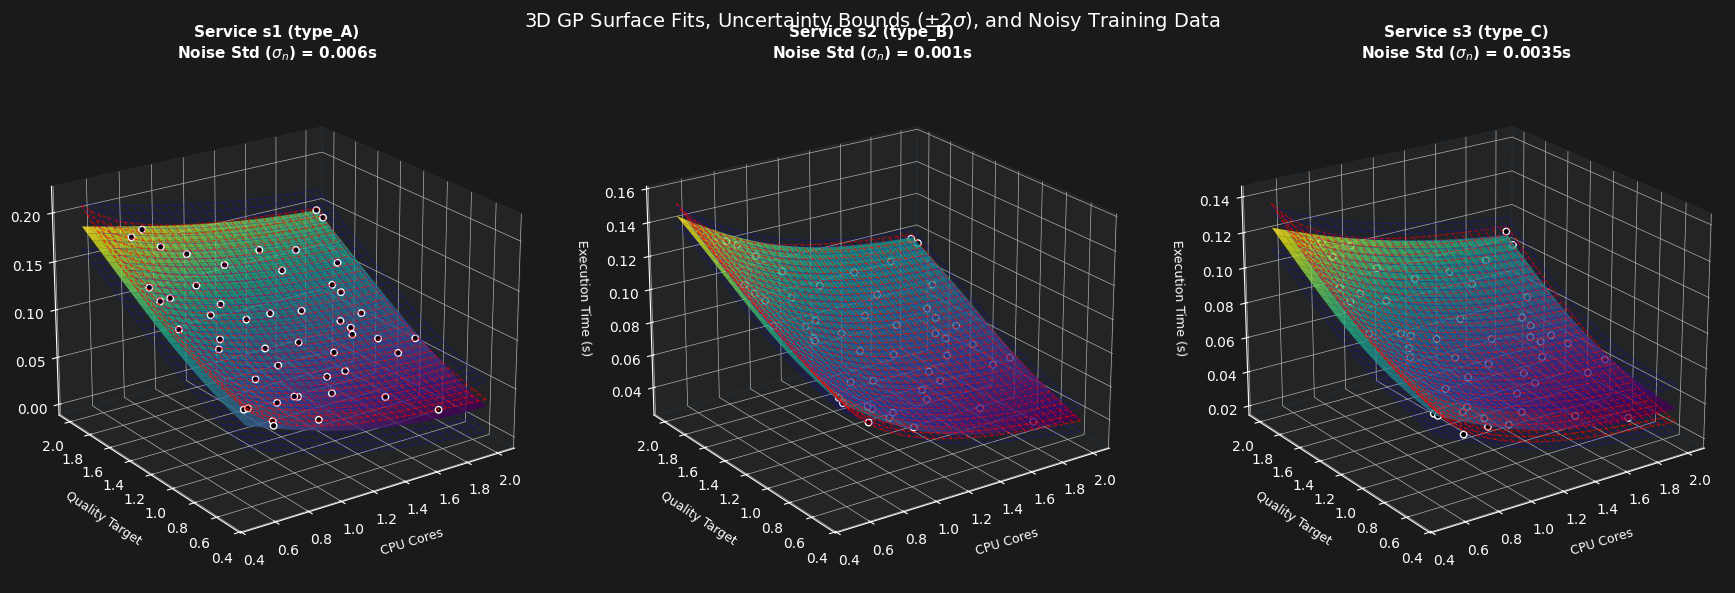

In [5]:
from mpl_toolkits.mplot3d import Axes3D

# Create 2D grid across both CPU (cores) and Quality
n_grid = 30
cpu_axis = np.linspace(0.5, 2.0, n_grid)
quality_axis = np.linspace(0.5, 2.0, n_grid)

CPU_grid, QUALITY_grid = np.meshgrid(cpu_axis, quality_axis)
PARALLELISM_grid = np.full_like(CPU_grid, 2.0)  # fixed parallelism

# Flatten grid for predictions
X_grid_3d = np.column_stack([
    CPU_grid.ravel(),
    QUALITY_grid.ravel(),
    PARALLELISM_grid.ravel()
])

fig = plt.figure(figsize=(18, 6), dpi=100)

for idx, (s_name, s_type) in enumerate(zip(service_names, service_types), 1):
    ax = fig.add_subplot(1, 3, idx, projection='3d')

    # Predict GP mean and standard deviation across 2D grid
    mu, std = gp_models[s_name].predict(X_grid_3d, return_std=True)
    mu_surface = mu.reshape(n_grid, n_grid)
    std_surface = std.reshape(n_grid, n_grid)

    # 1. Plot GP Predicted Mean Surface (Solid Mesh)
    surf_mean = ax.plot_surface(
        CPU_grid, QUALITY_grid, mu_surface,
        cmap='viridis', alpha=0.8, edgecolor='none', label=r"GP Mean $\mu(x)$"
    )

    # 2. Plot GP Uncertainty Envelope (+- 2 std) as transparent wireframes
    ax.plot_wireframe(
        CPU_grid, QUALITY_grid, mu_surface + 2 * std_surface,
        color='blue', linewidth=0.5, alpha=0.3, label=r"Upper Bound ($\mu + 2\sigma$)"
    )
    ax.plot_wireframe(
        CPU_grid, QUALITY_grid, mu_surface - 2 * std_surface,
        color='blue', linewidth=0.5, alpha=0.3, label=r"Lower Bound ($\mu - 2\sigma$)"
    )

    # 3. Plot True Demand (Red Dashed Wireframe)
    y_true_surface = true_demand(X_grid_3d, s_type).reshape(n_grid, n_grid)
    ax.plot_wireframe(
        CPU_grid, QUALITY_grid, y_true_surface,
        color='red', linewidth=0.8, linestyle='--', alpha=0.6, label=r"True Demand $f(x)$"
    )

    # 4. Scatter Training Samples with Vertical Drop Lines to see 3D position clearly
    x_train_cpu = X_train[:, 0]
    x_train_qual = X_train[:, 1]
    y_train_obs = y_train_dict[s_name]

    # Draw vertical stem lines connecting each point to the GP Mean
    for x_c, x_q, y_o in zip(x_train_cpu, x_train_qual, y_train_obs):
        # Predict mean at specific point to draw residual stem
        mu_pt = gp_models[s_name].predict(np.array([[x_c, x_q, 2.0]]))
        ax.plot([x_c, x_c], [x_q, x_q], [mu_pt[0], y_o], color='black', alpha=0.4, linewidth=0.8)

    # Scatter actual noisy observations
    ax.scatter(
        x_train_cpu, x_train_qual, y_train_obs,
        color='black', s=22, edgecolors='white', alpha=1.0, zorder=10, label="Observed Training Data"
    )

    # Aesthetics & Labels
    ax.set_title(f"Service {s_name} ({s_type})\nNoise Std ($\\sigma_n$) = {noise_levels[s_name]}s", fontsize=11, fontweight='bold')
    ax.set_xlabel("CPU Cores", fontsize=9, labelpad=8)
    ax.set_ylabel("Quality Target", fontsize=9, labelpad=8)
    ax.set_zlabel("Execution Time (s)", fontsize=9, labelpad=8)
    ax.view_init(elev=22, azim=-125)

plt.suptitle(r"3D GP Surface Fits, Uncertainty Bounds ($\pm 2\sigma$), and Noisy Training Data", fontsize=14, y=0.98)
plt.tight_layout()
plt.show()

## 4. Visualization: Coverage Analysis of the GP (Test Dataset)

We evaluate empirical coverage on a held-out test dataset to verify that the GP's predictive distribution holds at
the targeted violation probability $\alpha = 0.05$ (95% coverage).

**Changed:** this section checks step 1 only: whether a single new *execution time* falls below the GP's predictive
quantile $\mu + z\sigma$. It is not a check of the latency bound, which also includes queueing; that check is in
Section 6b. The test inputs are now drawn from the training range (change E).

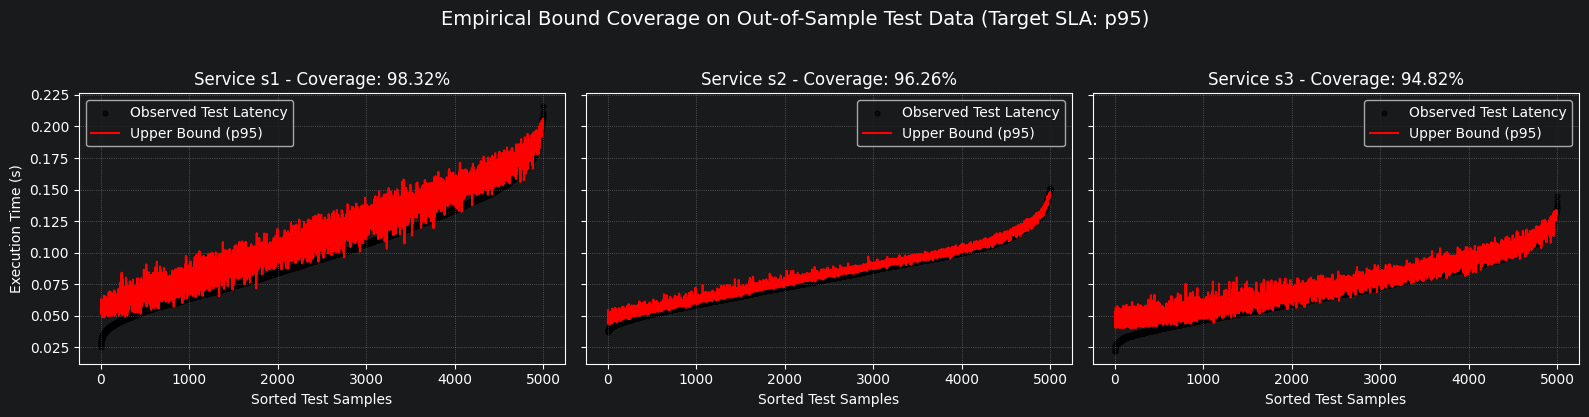

In [6]:
n_test = 5000
X_test = np.column_stack([
    np.random.uniform(0.5, 2.0, n_test),
    # CHANGED: Quality is drawn from the training range; the old line drew half of the test set outside it
    # np.random.uniform(0.0, 1.0, n_test),
    np.random.uniform(0.5, 2.0, n_test),
    np.random.uniform(1.0, 4.0, n_test)
])

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)

for ax, s_name, s_type in zip(axes, service_names, service_types):
    y_true_test = true_demand(X_test, s_type) + np.random.normal(0, noise_levels[s_name], n_test)
    mu_test, std_test = gp_models[s_name].predict(X_test, return_std=True)

    upper_bound = mu_test + (z_score * std_test)
    coverage = np.mean(y_true_test <= upper_bound) * 100

    sort_idx = np.argsort(y_true_test)

    ax.scatter(range(n_test), y_true_test[sort_idx], color='black', alpha=0.6, s=12, label="Observed Test Latency")
    ax.plot(range(n_test), upper_bound[sort_idx], color='red', linewidth=1.5, label=f"Upper Bound (p{p_str})")

    ax.set_title(f"Service {s_name} - Coverage: {coverage:.2f}%")
    ax.set_xlabel("Sorted Test Samples")
    if s_name == "s1":
        ax.set_ylabel("Execution Time (s)")
    ax.legend()
    ax.grid(True, linestyle=":", alpha=0.6)

plt.suptitle(f"Empirical Bound Coverage on Out-of-Sample Test Data (Target SLA: p{p_str})", fontsize=14, y=1.03)
plt.tight_layout()
plt.show()

## 5. Visualization: GP Tightness Analysis

Tightness measures the residual margin $\text{Bound}(x) - \text{Observed}(x)$ of the GP's predictive quantile against single
execution times. Lower positive values reflect a tight, non-pessimistic interval. (For latency bounds, Sections 6b–9
report tightness as the ratio bound ÷ measured quantile, as in the testbed evaluation.)

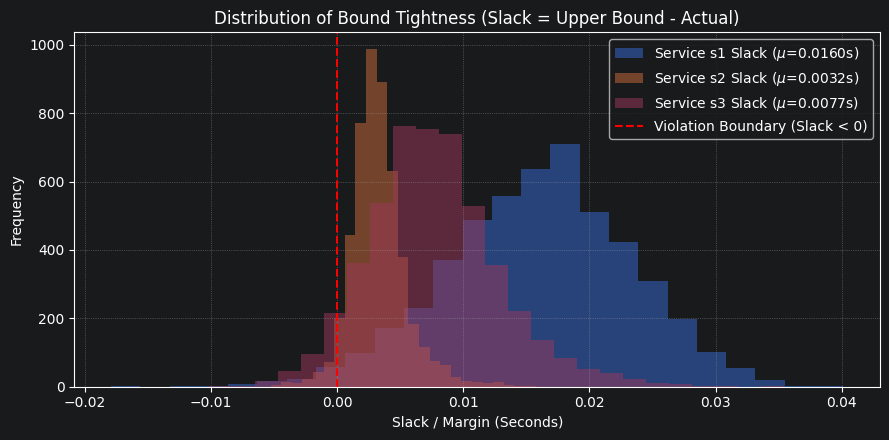

In [7]:
fig, ax = plt.subplots(figsize=(9, 4.5))

for s_name, s_type in zip(service_names, service_types):
    y_true_test = true_demand(X_test, s_type) + np.random.normal(0, noise_levels[s_name], n_test)
    mu_test, std_test = gp_models[s_name].predict(X_test, return_std=True)

    upper_bound = mu_test + z_score * std_test
    tightness = upper_bound - y_true_test

    # CHANGED: raw f-string, so "\mu" is not read as an escape sequence (SyntaxWarning in the old version)
    ax.hist(tightness, bins=25, alpha=0.5, label=rf"Service {s_name} Slack ($\mu$={np.mean(tightness):.4f}s)")

ax.axvline(0, color='red', linestyle='--', linewidth=1.5, label="Violation Boundary (Slack < 0)")
ax.set_title("Distribution of Bound Tightness (Slack = Upper Bound - Actual)", fontsize=12)
ax.set_xlabel("Slack / Margin (Seconds)")
ax.set_ylabel("Frequency")
ax.legend()
ax.grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()

## 6. Deriving SNC Service Bounds via MGFs

Using the predictive mean $\mu_i(x)$ and variance $\sigma_i^2(x)$ from the GP, we evaluate the closed-form Moment
Generating Function (MGF) $M_X(\theta) = \mathbb{E}[e^{\theta X}] = \exp\left(\theta \mu + \frac{\theta^2}{2}\sigma^2\right)$ of the execution time $X$.

**Changed (change B): from an execution-time bound to a latency bound.** The old function bounded one execution
time with Chernoff's inequality: $P(X \ge D) \le M_X(\theta)\,e^{-\theta D}$, giving $D = \mu + \sigma\sqrt{-2\ln\alpha}$.
It ignores the arrival rate $\lambda$ and the queue, so it is not a bound on latency.

The new bound uses the queue. An item's latency $W$ at a FIFO server is the largest backlog it finds:
$W = \max_{n \ge 0}\left(\sum_{i=0}^{n} X_i - \sum_{i=1}^{n} T_i\right)$, where the $X_i$ are the execution times of the item and the
$n$ items before it, and the $T_i$ are inter-arrival times, with $\mathbb{E}[e^{-\theta T}] = \lambda / (\lambda + \theta)$ for Poisson
arrivals. A union bound over $n$ and Chernoff's inequality for each term give

$$P(W > d) \;\le\; e^{-\theta d}\,\frac{M_X(\theta)}{1 - \rho(\theta)}, \qquad \rho(\theta) = M_X(\theta)\,\mathbb{E}[e^{-\theta T}] < 1,$$

which holds for any i.i.d. inter-arrival times (**change G**). For Poisson arrivals $\mathbb{E}[e^{-\theta T}] = \lambda / (\lambda + \theta)$;
for periodic arrivals with gaps $T = \frac{1}{\lambda}(1 + U)$, $U \sim \mathcal{U}(-j, j)$, it is
$\mathbb{E}[e^{-\theta T}] = e^{-\theta a}\,\frac{1 - e^{-\theta w}}{\theta w}$ with $a = (1 - j)/\lambda$ and $w = 2j/\lambda$
($e^{-\theta/\lambda}$ for $j = 0$). The latency bound at violation probability $\varepsilon$ is the best $\theta$:
$\;d(\varepsilon) = \min_\theta \frac{1}{\theta}\left[\ln M_X(\theta) - \ln(1 - \rho(\theta)) - \ln \varepsilon\right]$.
For $\lambda \to 0$, $\rho \to 0$ and this is exactly the old bound, so the old bound is the special case of an empty
queue. If $\rho(\theta) \ge 1$ for every $\theta$ (the service is overloaded) there is no finite bound.

**Changed (change D): epistemic uncertainty.** The old version added the epistemic variance to every item's variance
(Eq. 1 of the paper). But epistemic uncertainty is about the *configuration*, not about each item: it is one unknown
shared by all items, and added per item it averages out over the queue. The new version uses it as a confidence
level on the mean: $\mu^{+} = \mu + z_{95\%}\,\sigma_{\text{epistemic}}$, with the aleatoric $\sigma_n^2$ as the item variance.
Both treatments are compared in Section 6b.

In [8]:
# OLD (kept for reference): the first version, which mixed up rates and delays.
# def compute_snc_mgf_service_curve(model, x_test, theta=100.0, target_eps=0.05):
#     """Computes MGF-backed SNC guaranteed service rate."""
#     mu, std = model.predict(x_test, return_std=True)
#     var = std ** 2
#     log_mgf = theta * mu + 0.5 * (theta ** 2) * var
#     guaranteed_rate = (theta / log_mgf) - (np.log(target_eps) / (theta * log_mgf))
#     guaranteed_rate = np.maximum(guaranteed_rate, 1e-6)
#     return guaranteed_rate, mu, std, log_mgf


# OLD (kept as a baseline): Chernoff bound on a single execution time, no queue (= the new bound with lambda -> 0).
def compute_snc_mgf_delay_bound(model, x_cfg, alpha=0.01):
    """
    Computes the MGF-backed SNC single-node delay bound D_i(x) for target violation prob alpha.

    Using log M_Y(theta) = theta*mu + (theta^2 / 2)*var, Chernoff's bound gives:
    P(Y >= D) <= exp(log M_Y(theta) - theta*D) = alpha
    Solving for optimal theta* yields: theta* = sqrt(-2*ln(alpha) / var)
    Plugging theta* back yields: D_i(alpha) = mu + sqrt(-2*ln(alpha) * var)
    """
    mu, std_total, var_epistemic, var_aleatoric = model.predict(x_cfg, return_variance_components=True)
    var_total = std_total ** 2

    # Node-optimal MGF theta parameter
    theta_opt = np.sqrt(-2.0 * np.log(alpha) / var_total)

    # Closed-form log-MGF evaluated at theta*
    log_mgf_opt = theta_opt * mu + 0.5 * (theta_opt ** 2) * var_total

    # Minimum physical latency bound satisfying target violation probability alpha
    delay_bound = (log_mgf_opt - np.log(alpha)) / theta_opt

    return delay_bound, theta_opt, mu, std_total


# NEW (change D): what the bound believes about the execution time of one item.
def execution_time_belief(model, x_cfg, treatment="confidence"):
    """Returns (mean, item variance) of the execution time.
    'confidence'    : epistemic uncertainty as a confidence level on the mean (new default)
    'item_variance' : epistemic variance added to every item's variance (old, Eq. 1 of the paper)
    'plug_in'       : GP mean and aleatoric variance only"""
    mu, _, var_epistemic, var_aleatoric = model.predict(x_cfg, return_variance_components=True)
    if treatment == "confidence":
        return mu + z_confidence * np.sqrt(var_epistemic), var_aleatoric
    if treatment == "item_variance":
        return mu, var_epistemic + var_aleatoric
    return mu, var_aleatoric


# NEW (change G): ln E[exp(-theta T)] of the inter-arrival time T on theta_grid
def log_interarrival_mgf(arrival_rate):
    if arrival_process == "poisson":
        return np.log(arrival_rate / (arrival_rate + theta_grid))
    if arrival_process == "periodic":
        shortest_gap = (1 - arrival_jitter) / arrival_rate
        if arrival_jitter == 0:
            return -theta_grid * shortest_gap
        width = 2 * arrival_jitter / arrival_rate
        return -theta_grid * shortest_gap + np.log(-np.expm1(-theta_grid * width)) - np.log(theta_grid * width)
    raise ValueError(f"unknown arrival_process {arrival_process!r}")


# NEW (change B): SNC queueing bound on the latency of one FIFO service with renewal arrivals.
def log_latency_moment(mean, var, arrival_rate):
    """ln of M_X(theta) / (1 - rho(theta)) on theta_grid, one row per configuration; inf where rho >= 1."""
    mean, var = np.atleast_1d(mean)[:, None], np.atleast_1d(var)[:, None]
    log_mgf = theta_grid * mean + 0.5 * theta_grid ** 2 * var
    # CHANGED (change G): was log_mgf + np.log(arrival_rate / (arrival_rate + theta_grid)), i.e. Poisson only
    log_rho = log_mgf + log_interarrival_mgf(arrival_rate)
    stable = log_rho < 0
    moment = np.full(log_mgf.shape, np.inf)
    moment[stable] = log_mgf[stable] - np.log1p(-np.exp(log_rho[stable]))
    return moment


def latency_bound_from_moment(log_moment, epsilon):
    """d(epsilon) = min over theta of (log moment - ln epsilon) / theta."""
    return np.min((log_moment - np.log(epsilon)) / theta_grid, axis=1)


def snc_latency_bound(mean, var, arrival_rate, epsilon):
    return latency_bound_from_moment(log_latency_moment(mean, var, arrival_rate), epsilon)


print("SNC bound functions ready.")

SNC bound functions ready.


## 6b. Service-Level Bounds on Held-Out Configurations (RQ1)

**New.** For random test configurations, we simulate each service alone as a queue at rate $\lambda$ and compare its
measured $(1-\alpha)$ latency quantile with the bound. *Coverage* is the share of configurations whose measured
quantile is at or below the bound; *tightness* is the median of bound ÷ measured quantile.

The old execution-time bound is included to show what it misses: it does not account for queueing, so it is not a
latency bound.

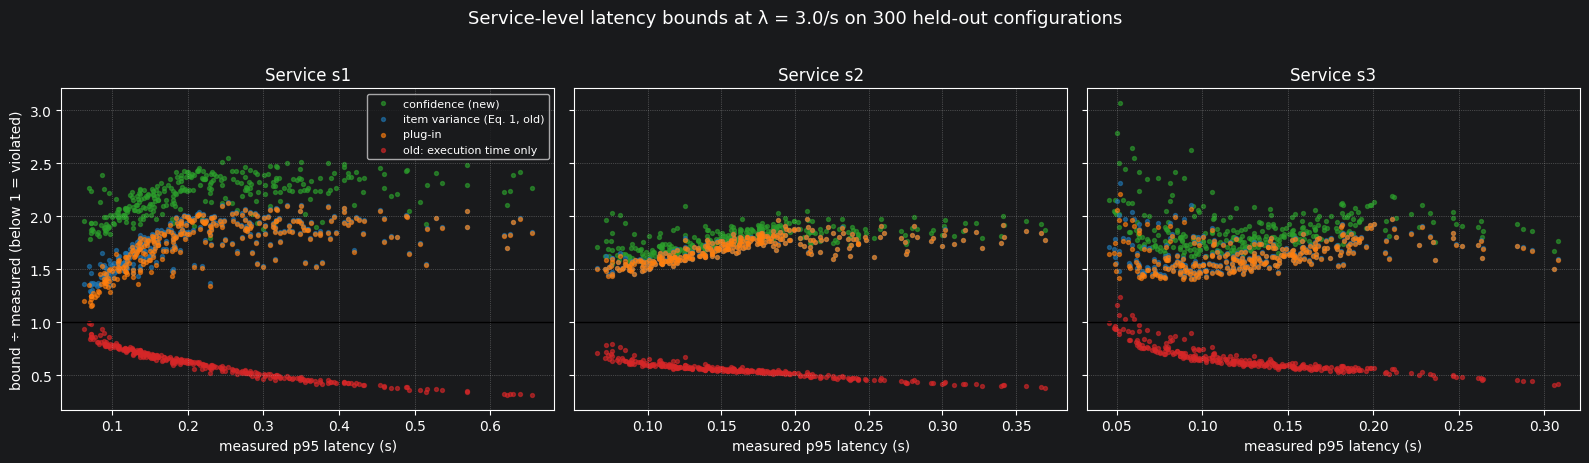

service  treatment                     coverage  tightness
s1       confidence (new)                100.0%      2.23x
s1       item variance (Eq. 1, old)      100.0%      1.81x
s1       plug-in                         100.0%      1.80x
s1       old: execution time only          0.0%      0.62x
s2       confidence (new)                100.0%      1.80x
s2       item variance (Eq. 1, old)      100.0%      1.70x
s2       plug-in                         100.0%      1.70x
s2       old: execution time only          0.0%      0.55x
s3       confidence (new)                100.0%      1.84x
s3       item variance (Eq. 1, old)      100.0%      1.63x
s3       plug-in                         100.0%      1.62x
s3       old: execution time only          2.0%      0.62x


In [9]:
rng = np.random.default_rng(7)

n_cfg_test = 300

X_cfg_test = np.column_stack([
    rng.uniform(0.5, 2.0, n_cfg_test),
    rng.uniform(0.5, 2.0, n_cfg_test),
    rng.uniform(1.0, 4.0, n_cfg_test)
])

single_node_results = {}
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=True)
for ax, s_name, s_type in zip(axes, service_names, service_types):
    _, latency = simulate_pipeline(X_cfg_test, [s_type], [noise_levels[s_name]], arrival_rate, n_sim_items, item_correlation, rng)
    measured = quantile_per_config(latency)

    bounds = {"confidence (new)": snc_latency_bound(*execution_time_belief(gp_models[s_name], X_cfg_test, "confidence"), arrival_rate, alpha),
              "item variance (Eq. 1, old)": snc_latency_bound(*execution_time_belief(gp_models[s_name], X_cfg_test, "item_variance"), arrival_rate, alpha),
              "plug-in": snc_latency_bound(*execution_time_belief(gp_models[s_name], X_cfg_test, "plug_in"), arrival_rate, alpha),
              "old: execution time only": compute_snc_mgf_delay_bound(gp_models[s_name], X_cfg_test, alpha=alpha)[0]}
    for name, bound in bounds.items():
        single_node_results[(s_name, name)] = {"coverage": np.mean(measured <= bound), "tightness": np.median(bound / measured)}

    for (name, bound), color in zip(bounds.items(), ["tab:green", "tab:blue", "tab:orange", "tab:red"]):
        ax.scatter(measured, bound / measured, s=8, alpha=0.6, color=color, label=name)
    ax.axhline(1.0, color="black", linewidth=1)
    ax.set_title(f"Service {s_name}")
    ax.set_xlabel(f"measured p{p_str} latency (s)")
    ax.grid(True, linestyle=":", alpha=0.6)
axes[0].set_ylabel("bound ÷ measured (below 1 = violated)")
axes[0].legend(fontsize=8)
plt.suptitle(f"Service-level latency bounds at λ = {arrival_rate}/s on {n_cfg_test} held-out configurations", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f"{'service':<8} {'treatment':<28} {'coverage':>9} {'tightness':>10}")
for (s_name, name), result in single_node_results.items():
    print(f"{s_name:<8} {name:<28} {result['coverage']:>9.1%} {result['tightness']:>9.2f}x")

**What this shows.**
- **The old bound is not a latency bound.** It bounds execution time and falls below the measured latency in almost
  every configuration, because it leaves out the queue.
- **The queueing bound covers every configuration** under all three treatments of epistemic uncertainty.
- **Eq. (1) adds almost nothing over the plug-in:** the epistemic variance per item averages out in the queue.
- **The confidence treatment is the most conservative.** It shifts the mean, which every item in the queue shares,
  so it moves the bound noticeably. It is the only treatment that responds to how much the GP actually knows about
  a configuration.

## 7. Composition & End-to-End Performance Analysis

**Changed (change C): the union bound is the PPG.** A request violates the end-to-end bound $\sum_k d_k$ only if it
violates at least one node bound $d_k$. So if every node bound is computed at $\varepsilon / K$ for a path of $K$ nodes,

$$P\Big(\sum_k W_k > \sum_k d_k(\varepsilon / K)\Big) \;\le\; \sum_k P\big(W_k > d_k(\varepsilon / K)\big) \;\le\; \varepsilon,$$

whatever the dependence between the services. For a DAG, the budget is split over all nodes and the bound is the
longest path.

**Old composition, kept as a baseline:** adding the means and variances and optimizing one $\theta$ multiplies the
node MGFs, which is only valid if the nodes are *independent*. The same holds for its queueing version below.
In this pipeline they are not independent: an item that is large at $s_1$ is large at $s_2$ and $s_3$, and queues
propagate downstream.

*On the old TODO "benefit of SNC vs the joint Gaussian":* if execution times were Gaussian and independent, the
joint Gaussian quantile would be exact and any Chernoff bound would be looser ($\sqrt{-2\ln\alpha} = 2.45$ vs
$z = 1.64$ standard deviations at $\alpha = 0.05$). That is why the old SNC bound came out above the naive sum. SNC
earns its place because it (1) bounds queueing latency from the MGF, which has no closed-form quantile, and (2)
composes with the union bound without assuming independence.

In [10]:
# Nominal Operating Point Configuration
x_pipeline_cfg = np.array([[1.0, 1.0, 2.0]])  # [CPU, Quality, Parallelism]
n_nodes = len(service_names)

# ------------------------------------------------------------------------------
# A. Node-Level Evaluation & Metric Collection
# ------------------------------------------------------------------------------
node_mus = []
node_stds = []
node_delays = []   # CHANGED: was node_rates; compute_snc_mgf_delay_bound returns a delay in seconds, not a rate
node_beliefs = []  # NEW: (mean, item variance) under the confidence treatment

print("\n=== Individual Node Performance Guarantees ===")
for s_name in service_names:
    model = gp_models[s_name]

    # Predict mean and standard deviation
    mu, std = model.predict(x_pipeline_cfg, return_std=True)

    # OLD: execution-time bound (no queue)
    delay, _, _, _ = compute_snc_mgf_delay_bound(model, x_pipeline_cfg, alpha=alpha)

    # NEW: latency bounds with queueing, at the full budget alpha and at the PPG share alpha / K
    belief = execution_time_belief(model, x_pipeline_cfg, "confidence")
    latency_full = snc_latency_bound(*belief, arrival_rate, alpha)[0]
    latency_share = snc_latency_bound(*belief, arrival_rate, alpha / n_nodes)[0]

    node_mus.append(mu[0])
    node_stds.append(std[0])
    node_delays.append(delay[0])
    node_beliefs.append(belief)

    # CHANGED: the old print labelled the delay bound as "Guaranteed Rate ... units/s"
    print(
        f"Service {s_name:2s} | "
        f"Pred exec time = {mu[0]:.4f}s (std = {std[0]:.4f}) | "
        f"old exec-time bound = {delay[0]:.4f}s | "
        f"latency bound at α = {latency_full:.4f}s, at α/K = {latency_share:.4f}s"
    )


=== Individual Node Performance Guarantees ===
Service s1 | Pred exec time = 0.0808s (std = 0.0100) | old exec-time bound = 0.1053s | latency bound at α = 0.3351s, at α/K = 0.3901s
Service s2 | Pred exec time = 0.0723s (std = 0.0016) | old exec-time bound = 0.0763s | latency bound at α = 0.2347s, at α/K = 0.2727s
Service s3 | Pred exec time = 0.0587s (std = 0.0045) | old exec-time bound = 0.0696s | latency bound at α = 0.1891s, at α/K = 0.2195s


In [11]:
# ------------------------------------------------------------------------------
# B. OLD: End-to-End Optimization & Convolution of execution times (independence, no queue)
# ------------------------------------------------------------------------------
mu_total = sum(node_mus)
var_total = sum(std ** 2 for std in node_stds)
std_total = np.sqrt(var_total)

# Global optimal theta* for end-to-end composition variance
theta_opt = np.sqrt(2 * -np.log(alpha) / var_total)

# E2E Log-MGF sum
e2e_log_mgf_opt = theta_opt * mu_total + 0.5 * (theta_opt ** 2) * var_total

# Physical latency bound (seconds)
e2e_latency_bound_opt = (e2e_log_mgf_opt - np.log(alpha)) / theta_opt
# CHANGED: removed e2e_bottleneck_rate = min(node_rates); node_rates were delays, and their minimum has no meaning

# ------------------------------------------------------------------------------
# B2. NEW: composition of latency bounds (with queueing)
# ------------------------------------------------------------------------------
# PPG: union bound, every node at alpha / K. Valid for any dependence between nodes.
ppg_bound = sum(snc_latency_bound(*belief, arrival_rate, alpha / n_nodes)[0] for belief in node_beliefs)
# Additive: every node at alpha, without splitting. Common practice, no guarantee.
additive_bound = sum(snc_latency_bound(*belief, arrival_rate, alpha)[0] for belief in node_beliefs)
# Independent SNC convolution: multiply the node latency MGFs, one theta. The old composition with queueing; needs independence.
independent_bound = latency_bound_from_moment(sum(log_latency_moment(*belief, arrival_rate) for belief in node_beliefs), alpha)[0]

# ------------------------------------------------------------------------------
# C. Empirical Oracle Real Latency (Monte Carlo Ground Truth)
# ------------------------------------------------------------------------------
np.random.seed(42)
n_samples = 100_000

# simulated_latencies = np.zeros(n_samples)
# for s_name in service_names:
#     model = gp_models[s_name]
#     mu_s, std_s = model.predict(x_pipeline_cfg, return_std=True)
#     simulated_latencies += np.random.normal(mu_s[0], std_s[0], n_samples)
#
# oracle_real_p_latency = np.percentile(simulated_latencies, (1 - alpha) * 100)

# OLD oracle: sum of independent execution times, no queue (change A)
simulated_latencies = np.zeros(n_samples)
for s_name, s_type in zip(service_names, service_types):
    # Sample from physical ground truth true_demand() instead of GP prediction
    true_latent = true_demand(x_pipeline_cfg, s_type)[0]
    simulated_latencies += np.random.normal(true_latent, noise_levels[s_name], n_samples)

oracle_real_p_latency = np.percentile(simulated_latencies, (1 - alpha) * 100)

# NEW oracle: the queueing pipeline (Section 1b)
rng = np.random.default_rng(42)
nominal_node_latencies, nominal_latencies = simulate_pipeline(
    np.repeat(x_pipeline_cfg, 20, axis=0), service_types, [noise_levels[s] for s in service_names],
    arrival_rate, n_sim_items, item_correlation, rng)
oracle_queueing_p_latency = np.quantile(nominal_latencies, 1 - alpha)

# NEW: is independence a safe assumption? Shuffle each node's latencies across items, which keeps every node's
# distribution but removes the dependence, and compare the resulting quantile with the real one.
independent_latencies = sum(rng.permuted(nominal_node_latencies[:, :, k], axis=1) for k in range(n_nodes))
oracle_independent_p_latency = np.quantile(independent_latencies, 1 - alpha)

# ------------------------------------------------------------------------------
# D. Baselines Summary
# ------------------------------------------------------------------------------
b1_sum_of_means = mu_total
b2_naive_sum_p = sum(m + z_score * s for m, s in zip(node_mus, node_stds))
# CHANGED: the old TODO "how the confidence is messed up": b2 uses alpha at every node (no split) and b3 assumes
# independence, so neither is a guarantee; see the markdown above.
b3_joint_gaussian_p = mu_total + z_score * std_total
# CHANGED: old TODO "benefit of the SNC vs the joint Gaussian" is answered in the markdown above.
b4_snc_mgf_bound = e2e_latency_bound_opt
b5_oracle_real_p = oracle_real_p_latency

print("\n" + "=" * 100)
print(f"{'E2E LATENCY BOUND COMPARISON (target alpha = ' + str(alpha) + ', lambda = ' + str(arrival_rate) + '/s, ' + arrival_process + ' arrivals)':^100}")
print("=" * 100)
print(f"{'Method / Baseline':<42} | {'Latency (s)':<11} | {'Notes / Interpretation'}")
print("-" * 100)
print(f"{'OLD 1. Sum of Means (E[Y])':<42} | {b1_sum_of_means:<11.4f} | Mean execution time only (no tail risk, no queue)")
print(f"{f'OLD 2. Naive Sum of p{p_str} Exec. Times':<42} | {b2_naive_sum_p:<11.4f} | No queue; alpha at every node")
print(f"{f'OLD 3. Joint Gaussian {p_str}% Quantile':<42} | {b3_joint_gaussian_p:<11.4f} | No queue; assumes independence")
print(f"{'OLD 4. SNC MGF Bound on Exec. Times':<42} | {b4_snc_mgf_bound:<11.4f} | No queue; assumes independence")
print(f"{f'OLD 5. Oracle p{p_str}, independent, no queue':<42} | {b5_oracle_real_p:<11.4f} | Old ground truth")
print("-" * 100)
print(f"{'NEW  Additive latency bounds (alpha each)':<42} | {additive_bound:<11.4f} | No guarantee: budget not split")
print(f"{'NEW  Independent SNC convolution':<42} | {independent_bound:<11.4f} | No guarantee: assumes independence")
print(f"{'NEW  PPG: union bound (alpha / K each)':<42} | {ppg_bound:<11.4f} | Guarantee for any dependence")
print(f"{f'NEW  Oracle p{p_str}, queueing pipeline':<42} | {oracle_queueing_p_latency:<11.4f} | New ground truth")
print(f"{f'NEW  Oracle p{p_str}, nodes made independent':<42} | {oracle_independent_p_latency:<11.4f} | Same node latencies, dependence removed")
print("=" * 100)


        E2E LATENCY BOUND COMPARISON (target alpha = 0.05, lambda = 3.0/s, poisson arrivals)        
Method / Baseline                          | Latency (s) | Notes / Interpretation
----------------------------------------------------------------------------------------------------
OLD 1. Sum of Means (E[Y])                 | 0.2118      | Mean execution time only (no tail risk, no queue)
OLD 2. Naive Sum of p95 Exec. Times        | 0.2383      | No queue; alpha at every node
OLD 3. Joint Gaussian 95% Quantile         | 0.2300      | No queue; assumes independence
OLD 4. SNC MGF Bound on Exec. Times        | 0.2389      | No queue; assumes independence
OLD 5. Oracle p95, independent, no queue   | 0.2215      | Old ground truth
----------------------------------------------------------------------------------------------------
NEW  Additive latency bounds (alpha each)  | 0.7589      | No guarantee: budget not split
NEW  Independent SNC convolution           | 0.5486      | No guarante

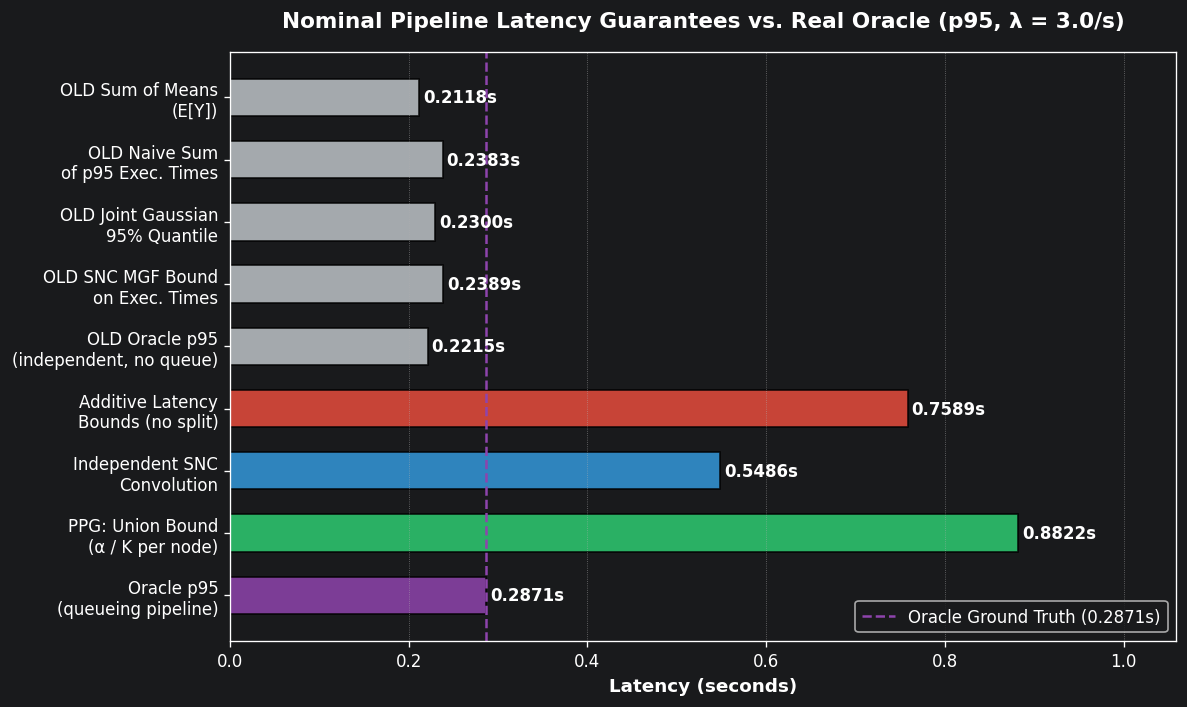

In [12]:
# ------------------------------------------------------------------------------
# E. Visualization: Nominal Configuration Bar Chart
# ------------------------------------------------------------------------------
# CHANGED: old bars (grey, execution times only) next to the new latency bounds (colored)
labels = [
    'OLD Sum of Means\n(E[Y])',
    f'OLD Naive Sum\nof p{p_str} Exec. Times',
    f'OLD Joint Gaussian\n{p_str}% Quantile',
    'OLD SNC MGF Bound\non Exec. Times',
    f'OLD Oracle p{p_str}\n(independent, no queue)',
    'Additive Latency\nBounds (no split)',
    'Independent SNC\nConvolution',
    'PPG: Union Bound\n(α / K per node)',
    f'Oracle p{p_str}\n(queueing pipeline)'
]
values = [
    b1_sum_of_means,
    b2_naive_sum_p,
    b3_joint_gaussian_p,
    b4_snc_mgf_bound,
    b5_oracle_real_p,
    additive_bound,
    independent_bound,
    ppg_bound,
    oracle_queueing_p_latency
]
colors = ['#bdc3c7'] * 5 + ['#e74c3c', '#3498db', '#2ecc71', '#8e44ad']

plt.figure(figsize=(10, 6), dpi=120)
bars = plt.barh(labels, values, color=colors, edgecolor='black', alpha=0.85, height=0.6)

plt.axvline(
    x=oracle_queueing_p_latency,
    color='#8e44ad',
    linestyle='--',
    linewidth=1.5,
    label=f'Oracle Ground Truth ({oracle_queueing_p_latency:.4f}s)'
)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.004,
        bar.get_y() + bar.get_height()/2,
        f'{width:.4f}s',
        va='center',
        ha='left',
        fontsize=10,
        fontweight='bold'
    )

plt.xlim(0, max(values) * 1.2)
plt.xlabel('Latency (seconds)', fontsize=11, fontweight='bold')
plt.title(
    f'Nominal Pipeline Latency Guarantees vs. Real Oracle (p{p_str}, λ = {arrival_rate}/s)',
    fontsize=13,
    fontweight='bold',
    pad=15
)
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle=':', alpha=0.6)
plt.legend(loc='lower right', frameon=True)
plt.tight_layout()
plt.show()

**What this shows.**
- **The old bounds (grey) all fall below the new ground truth.** They describe execution times, not latencies.
- **Of the latency bounds, only the PPG is a guarantee.** It is also the loosest: it pays for not assuming
  independence.
- **The last line of the table checks the independence assumption directly.** It takes the same simulated node
  latencies and removes their dependence by shuffling. Its quantile is slightly *below* the real one, so assuming
  independence under-estimates the tail. The error is small here, but it is systematic (Section 9).

## 8. Design Space Sensitivity & Sweep Analysis

To ensure our SNC bounds hold consistently across different system allocations, we sweep CPU availability and quality
($0.5 \to 2.0$) while tracking bound tightness and pessimism.

**Changed (change F):** the bound is the PPG (union bound over latency bounds) and the oracle is the simulated
queueing pipeline. Tightness is the ratio PPG ÷ measured p95; the old slack in percent over the old oracle is kept as a
comment. The simulation is vectorized over the grid and takes a few seconds.

PPG coverage over the grid: 100.0% of 1225 configurations; tightness median 3.17x (range 2.78x – 3.79x)


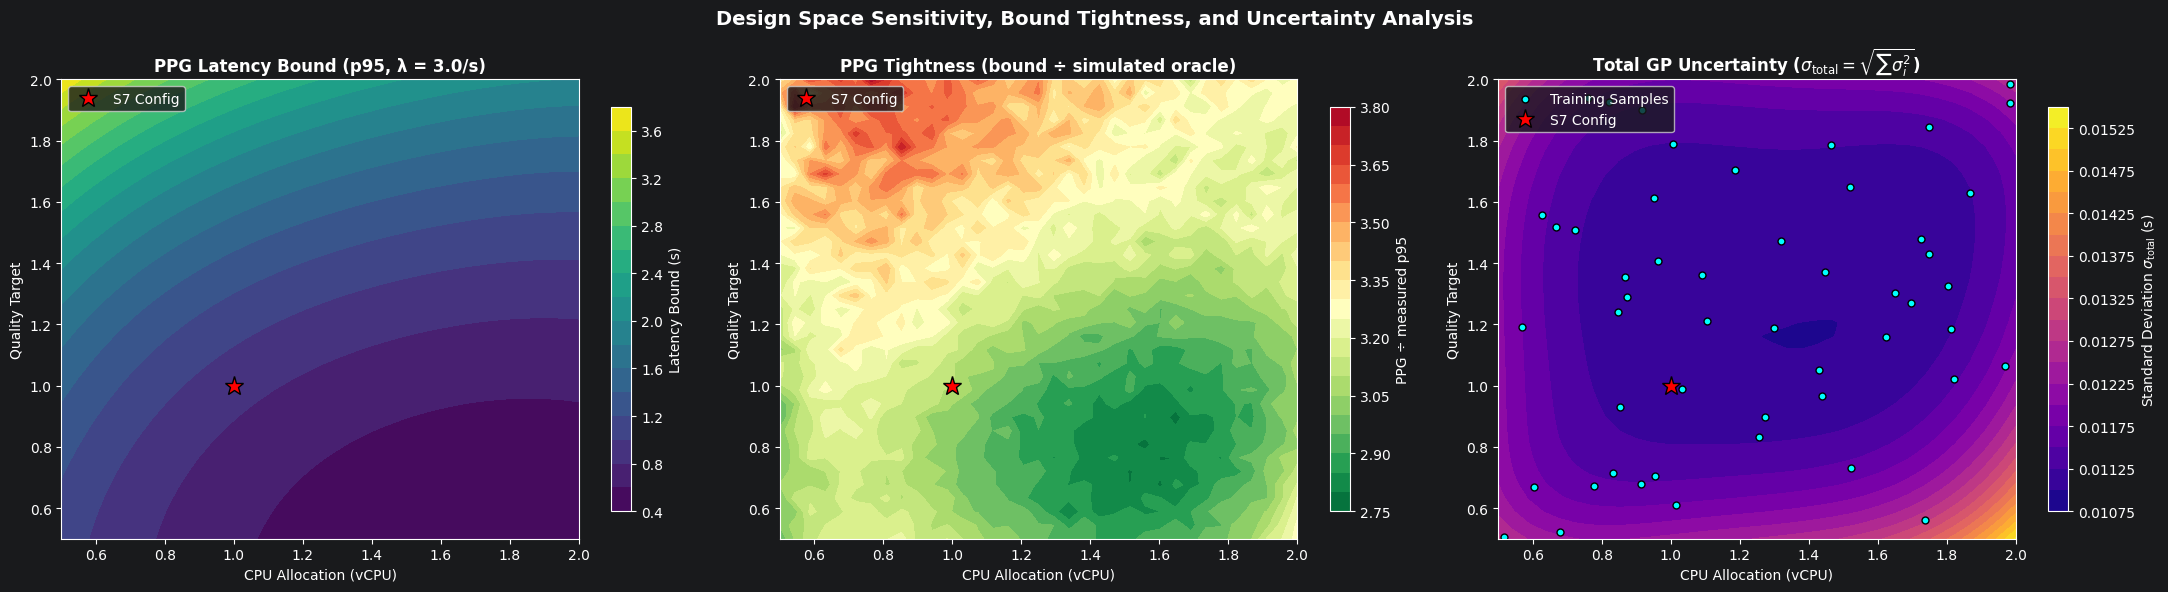

In [13]:
# ------------------------------------------------------------------------------
# A. Build 2D Meshgrid & Storage Matrices
# ------------------------------------------------------------------------------
n_grid = 35  # 35 x 35 = 1,225 evaluation points
cpu_axis = np.linspace(0.5, 2.0, n_grid)
quality_axis = np.linspace(0.5, 2.0, n_grid)

CPU_grid, QUALITY_grid = np.meshgrid(cpu_axis, quality_axis)
PARALLELISM_grid = np.full_like(CPU_grid, 2.0)

# Flatten grid for batched GP predictions
X_2d_sweep = np.column_stack([
    CPU_grid.ravel(),
    QUALITY_grid.ravel(),
    PARALLELISM_grid.ravel()
])

# ------------------------------------------------------------------------------
# B. CHANGED: Evaluate PPG Bounds, Oracle Ground Truth & Uncertainty (vectorized)
# ------------------------------------------------------------------------------
# OLD loop body per grid point (execution times only, independent):
#     theta_opt_i = np.sqrt(2 * -np.log(alpha) / var_tot_i)
#     e2e_log_mgf_i = theta_opt_i * mu_tot_i + 0.5 * (theta_opt_i ** 2) * var_tot_i
#     snc_bound_i = (e2e_log_mgf_i - np.log(alpha)) / theta_opt_i
#     mc_sim += np.random.normal(true_latent, noise_levels[s_name], n_mc_samples)   # sum of independent Gaussians
#     slack_surface[i] = ((snc_bound_i - oracle_p_i) / oracle_p_i) * 100
sweep_beliefs = [execution_time_belief(gp_models[s_name], X_2d_sweep, "confidence") for s_name in service_names]
ppg_surface = sum(snc_latency_bound(*belief, arrival_rate, alpha / n_nodes) for belief in sweep_beliefs)

std_total_surface = np.sqrt(sum(gp_models[s_name].predict(X_2d_sweep, return_std=True)[1] ** 2 for s_name in service_names))

rng = np.random.default_rng(42)
_, sweep_latencies = simulate_pipeline(X_2d_sweep, service_types, [noise_levels[s] for s in service_names],
                                       arrival_rate, n_sim_items, item_correlation, rng)
oracle_surface = quantile_per_config(sweep_latencies)
ratio_surface = ppg_surface / oracle_surface

print(f"PPG coverage over the grid: {np.mean(oracle_surface <= ppg_surface):.1%} of {len(X_2d_sweep)} configurations; "
      f"tightness median {np.median(ratio_surface):.2f}x (range {ratio_surface.min():.2f}x – {ratio_surface.max():.2f}x)")

# Reshape flattened results back to 2D matrix shape
PPG_matrix = ppg_surface.reshape(n_grid, n_grid)
Ratio_matrix = ratio_surface.reshape(n_grid, n_grid)
Std_Total_matrix = std_total_surface.reshape(n_grid, n_grid)

# ------------------------------------------------------------------------------
# C. Side-by-Side Unified Plotting (1 Row x 3 Columns - Clean 2D Grid)
# ------------------------------------------------------------------------------
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(22, 6), dpi=100)

# S7 nominal configuration point
s7_cpu = x_pipeline_cfg[0, 0]
s7_quality = x_pipeline_cfg[0, 1]
s7_label = f'S7 Config'

# Subplot 1: Absolute Latency Bound Surface (2D Contour)
c1 = ax1.contourf(CPU_grid, QUALITY_grid, PPG_matrix, levels=20, cmap='viridis')
fig.colorbar(c1, ax=ax1, shrink=0.88, label='Latency Bound (s)')
ax1.plot(s7_cpu, s7_quality, 'r*', markersize=14, markeredgecolor='black', label=s7_label)
ax1.set_title(f'PPG Latency Bound (p{p_str}, λ = {arrival_rate}/s)', fontsize=12, fontweight='bold')
ax1.set_xlabel('CPU Allocation (vCPU)', fontsize=10)
ax1.set_ylabel('Quality Target', fontsize=10)
ax1.legend(loc='upper left', frameon=True)

# Subplot 2: CHANGED: tightness ratio instead of slack in percent; the dashed line marks ratio 1 (violation below it)
c2 = ax2.contourf(CPU_grid, QUALITY_grid, Ratio_matrix, levels=20, cmap='RdYlGn_r')
fig.colorbar(c2, ax=ax2, shrink=0.88, label='PPG ÷ measured p95')
ax2.plot(s7_cpu, s7_quality, 'r*', markersize=14, markeredgecolor='black', label=s7_label)
if Ratio_matrix.min() < 1.0:
    contour_one = ax2.contour(CPU_grid, QUALITY_grid, Ratio_matrix, levels=[1.0], colors='black', linewidths=2.0, linestyles='--')
    ax2.clabel(contour_one, inline=True, fmt='violation', fontsize=9)
ax2.set_title('PPG Tightness (bound ÷ simulated oracle)', fontsize=12, fontweight='bold')
ax2.set_xlabel('CPU Allocation (vCPU)', fontsize=10)
ax2.set_ylabel('Quality Target', fontsize=10)
ax2.legend(loc='upper left', frameon=True)

# Subplot 3: Total GP Uncertainty Surface (2D Contour - Perfectly Aligned)
c3 = ax3.contourf(CPU_grid, QUALITY_grid, Std_Total_matrix, levels=20, cmap='plasma')
fig.colorbar(c3, ax=ax3, shrink=0.88, label=r'Standard Deviation $\sigma_{\mathrm{total}}$ (s)')

# Scatter training data points
ax3.scatter(X_train[:, 0], X_train[:, 1], color='cyan', edgecolors='black', s=25, label='Training Samples')

# Plot S7 point
ax3.plot(s7_cpu, s7_quality, 'r*', markersize=14, markeredgecolor='black', label=s7_label)

ax3.set_title(r'Total GP Uncertainty ($\sigma_{\mathrm{total}} = \sqrt{\sum \sigma_i^2}$)', fontsize=12, fontweight='bold')
ax3.set_xlabel('CPU Allocation (vCPU)', fontsize=10)
ax3.set_ylabel('Quality Target', fontsize=10)
ax3.legend(loc='upper left', frameon=True)

plt.suptitle("Design Space Sensitivity, Bound Tightness, and Uncertainty Analysis", fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

## 9. Composition vs. Depth (RQ2)

**New.** Chains of $K$ services, cycling through $s_1, s_2, s_3$ (every node has its own queue), at random held-out
configurations shared by all nodes (the global-quality assumption). For every depth we compare the PPG with the two
compositions that carry no guarantee, and with two oracles that use the *measured* node latencies instead of the
node bounds: one composes them with the union bound (this isolates what the union bound itself costs), the other
combines them as if they were independent (this shows directly whether independence is a safe assumption, without any
model error).

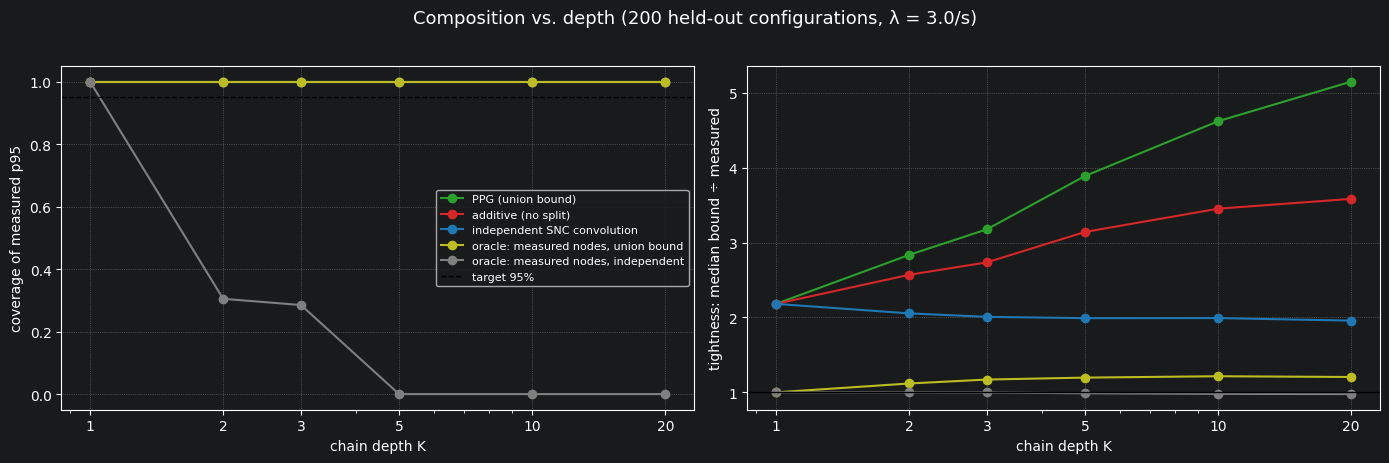

depth composition                             coverage  tightness
    1 PPG (union bound)                         100.0%      2.18x
    1 additive (no split)                       100.0%      2.18x
    1 independent SNC convolution               100.0%      2.18x
    1 oracle: measured nodes, union bound       100.0%      1.00x
    1 oracle: measured nodes, independent       100.0%      1.00x
    2 PPG (union bound)                         100.0%      2.83x
    2 additive (no split)                       100.0%      2.57x
    2 independent SNC convolution               100.0%      2.05x
    2 oracle: measured nodes, union bound       100.0%      1.12x
    2 oracle: measured nodes, independent        30.5%      1.00x
    3 PPG (union bound)                         100.0%      3.18x
    3 additive (no split)                       100.0%      2.74x
    3 independent SNC convolution               100.0%      2.01x
    3 oracle: measured nodes, union bound       100.0%      1.17x
    3 orac

In [14]:
depths = [1, 2, 3, 5, 10, 20]
n_cfg_depth = 200
rng = np.random.default_rng(11)
X_cfg_depth = np.column_stack([
    rng.uniform(0.5, 2.0, n_cfg_depth),
    rng.uniform(0.5, 2.0, n_cfg_depth),
    rng.uniform(1.0, 4.0, n_cfg_depth)
])
beliefs_by_service = {s_name: execution_time_belief(gp_models[s_name], X_cfg_depth, "confidence") for s_name in service_names}

depth_rows = []
for depth in depths:
    path = [service_names[k % 3] for k in range(depth)]
    node_latencies, latencies = simulate_pipeline(X_cfg_depth, [service_types[k % 3] for k in range(depth)],
                                                  [noise_levels[s] for s in path], arrival_rate, n_sim_items, item_correlation, rng)
    measured = quantile_per_config(latencies)
    shuffled = sum(rng.permuted(node_latencies[:, :, k], axis=1) for k in range(depth))
    compositions = {
        "PPG (union bound)": sum(snc_latency_bound(*beliefs_by_service[s], arrival_rate, alpha / depth) for s in path),
        "additive (no split)": sum(snc_latency_bound(*beliefs_by_service[s], arrival_rate, alpha) for s in path),
        "independent SNC convolution": latency_bound_from_moment(sum(log_latency_moment(*beliefs_by_service[s], arrival_rate) for s in path), alpha),
        "oracle: measured nodes, union bound": sum(quantile_per_config(node_latencies[:, :, k], 1 - alpha / depth) for k in range(depth)),
        "oracle: measured nodes, independent": quantile_per_config(shuffled),
    }
    for name, bound in compositions.items():
        depth_rows.append({"depth": depth, "composition": name, "coverage": np.mean(measured <= bound), "tightness": np.median(bound / measured)})

fig, (ax_cov, ax_tight) = plt.subplots(1, 2, figsize=(14, 4.5))
for name, color in zip(["PPG (union bound)", "additive (no split)", "independent SNC convolution",
                        "oracle: measured nodes, union bound", "oracle: measured nodes, independent"],
                       ["tab:green", "tab:red", "tab:blue", "tab:olive", "tab:gray"]):
    rows = [row for row in depth_rows if row["composition"] == name]
    ax_cov.plot(depths, [row["coverage"] for row in rows], "o-", color=color, label=name)
    ax_tight.plot(depths, [row["tightness"] for row in rows], "o-", color=color, label=name)
ax_cov.axhline(1 - alpha, color="black", linestyle="--", linewidth=1, label=f"target {1 - alpha:.0%}")
ax_cov.set_ylabel(f"coverage of measured p{p_str}")
ax_tight.axhline(1.0, color="black", linewidth=1)
ax_tight.set_ylabel("tightness: median bound ÷ measured")
for ax in (ax_cov, ax_tight):
    ax.set_xscale("log")
    ax.set_xticks(depths, [str(d) for d in depths])
    ax.set_xlabel("chain depth K")
    ax.grid(True, linestyle=":", alpha=0.6)
ax_cov.legend(fontsize=8)
plt.suptitle(f"Composition vs. depth ({n_cfg_depth} held-out configurations, λ = {arrival_rate}/s)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f"{'depth':>5} {'composition':<38} {'coverage':>9} {'tightness':>10}")
for row in depth_rows:
    print(f"{row['depth']:>5} {row['composition']:<38} {row['coverage']:>9.1%} {row['tightness']:>9.2f}x")

**What this shows.**
- **The PPG covers every configuration at every depth.**
- **Independence does not hold.** Combining the *measured* node latencies as if independent lands just below the
  real quantile (bound ÷ measured slightly under 1). From a few nodes on it misses almost every configuration. The
  independent SNC convolution still covers here, but only because the node bounds it multiplies are loose. It
  gives no guarantee.
- **The slack comes from the node bounds, not from the union bound.** Composing the *measured* node latencies with
  the union bound is much tighter than the PPG, even though its budget per node shrinks to α/K. Most of the PPG's
  slack comes from the node bounds, and it grows downstream. Every node bound assumes Poisson arrivals, but a
  downstream service receives the departures of the service before it. Those are smoother, so it queues much less
  than the bound assumes. The testbed evaluation (`evaluation_v2`) finds the same: the per-node queueing model,
  not the GP and not the composition, is the main source of slack, and it grows downstream.

In [15]:
# # 2D Active Learning Heatmap
# plt.figure(figsize=(8, 6), dpi=100)
# c = plt.contourf(CPU_grid, QUALITY_grid, Std_Total_matrix, levels=20, cmap='plasma')
# plt.colorbar(c, label=r'GP Uncertainty $\sigma_{\mathrm{total}}$ (s)')
#
# # Highlight maximum uncertainty point (where to sample next)
# max_idx = np.argmax(std_total_surface)
# plt.plot(X_2d_sweep[max_idx, 0], X_2d_sweep[max_idx, 1], 'r*', markersize=15,
#          label='Next Recommended Training Sample')
#
# plt.scatter(X_train[:, 0], X_train[:, 1], color='cyan', edgecolors='black', s=30, label='Existing Training Data')
# plt.title('Active Learning Guide: Regions Needing More Telemetry', fontsize=12, fontweight='bold')
# plt.xlabel('CPU Allocation (vCPU)')
# plt.ylabel('Quality Target')
# plt.legend(loc='lower right')
# plt.show()